In [1]:
import numpy as np
import polars as pl
import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import scipy.stats

def aggregate_epoch(epoch):
    """
    epoch: 2D array (window_length, num_features)
    Returns: 1D array of aggregated features per feature (mean, std, iqr, high_percentile, low_percentile, slope, delta, etc.)
    """
    # Basic stats
    mean = np.mean(epoch, axis=0)
    std = np.std(epoch, axis=0)
    # iqr = scipy.stats.iqr(epoch, axis=0, nan_policy='omit')
    high = np.percentile(epoch, 97, axis=0)
    low = np.percentile(epoch, 3, axis=0)

    # Trend features (optional but recommended)
    W = epoch.shape[0]
    slope = np.polyfit(np.arange(W), epoch, 1)[0] if W > 1 else np.zeros(epoch.shape[1])
    delta = epoch[-1] - epoch[0] if W > 0 else np.zeros(epoch.shape[1])

    # Concatenate all
    return np.concatenate([mean, std, high, low, slope, delta]) #iqr

In [3]:
def build_training_data_with_ids_epoch(df, feature_cols, window=7):
    """
    Uses the epoch split approach (5 overlapping windows) and returns engine IDs.
    window: number of cycles per split (e.g., 7)
    """
    X_list, y_list, id_list = [], [], []

    for _, group in df.group_by(["file_path", "Unit"]):
        engine_id = group["Unit"][0]
        group = group.sort("Cycle", descending=True)   # most recent first
        data = group[feature_cols].to_numpy()
        labels = group["RUL"].to_numpy()
        L = data.shape[0]

        # Need at least 3*window cycles to form all splits
        if L < 3 * window:
            continue   # or pad? For training, we can skip engines with too few cycles

        for i in range(3*window, L):
            # Ensure indices are valid: i is the index of the target cycle (most recent in window)
            # split_1: last 'window' cycles ending at i
            split_1 = aggregate_epoch(data[i-window+1 : i+1])
            # split_2: previous 'window' cycles
            # split_2 = aggregate_epoch(data[i-2*window+1 : i-window+1])
            # split_3: concatenation of split_1 and split_2 (i.e., last 2*window cycles)
            # split_3 = aggregate_epoch(data[i-2*window+1 : i+1])
            # split_4: previous 'window' before split_2
            # split_4 = aggregate_epoch(data[i-3*window+1 : i-2*window+1])
            # split_5: last 3*window cycles
            # split_5 = aggregate_epoch(data[i-3*window+1 : i-1*window+1])

            # Concatenate all split features
            features = np.concatenate([split_1])#split_2,  split_4,split_5, split_3
            X_list.append(features)
            y_list.append(labels[i])   # RUL at the target cycle
            id_list.append(engine_id)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(id_list)

In [4]:
def build_test_data_with_ids_epoch(df, labels, feature_cols, window=11):
    """
    For each test engine, take the last 3*window cycles (pad if needed)
    and compute the 5 splits. Returns X, y (labels are provided separately).
    """
    X_list, y_list, id_list = [], [], []

    for idx, (_, group) in enumerate(df.group_by(["file_path", "Unit"])):
        engine_id = group["Unit"][0]
        group = group.sort("Cycle", descending=True)
        data = group[feature_cols].to_numpy()
        L = data.shape[0]

        # Pad at the beginning with zeros if L < 3*window
        if L < 3 * window:
            pad_len = 3*window - L
            data = np.vstack([np.zeros((pad_len, data.shape[1])), data])
            L = data.shape[0]   # now L = 3*window

        # Now take the last 3*window cycles (which is the whole data after padding)
        # The target index is the last cycle (i = L-1)
        i = L - 1
        split_1 = aggregate_epoch(data[i-window+1 : i+1])
        # split_2 = aggregate_epoch(data[i-2*window+1 : i-window+1])
        # split_3 = aggregate_epoch(data[i-2*window+1 : i+1])
        # split_4 = aggregate_epoch(data[i-3*window+1 : i-2*window+1])
        # split_5 = aggregate_epoch(data[i-3*window+1 : i+1])

        features = np.concatenate([split_1])#,, split_2, split_4split_3, , split_5
        X_list.append(features)
        y_list.append(labels[idx])   # labels are provided per engine in order
        id_list.append(engine_id)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(id_list)

In [5]:
COLS = ["Unit", "Cycle", "Os1", "Os2", "Os3"] + [f"Sens_{i}" for i in range(21)]

lazy_df = pl.scan_csv(
    f"../CMAPSSData/train_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
)
processed_lazy_df = lazy_df.with_columns(  #Calculating target variable for all training data
    (pl.col("Cycle").max().over(["file_path", "Unit"]) - pl.col("Cycle")).alias("RUL")
).drop(["column_27", "column_28"])  #"file_path"

df = processed_lazy_df.collect()

In [6]:
WINDOW = 30   # choose a reasonable window size
FEATURES = [
    'Cycle', 'Os1', 'Os2', 'Os3',
    "Sens_1","Sens_2","Sens_3", "Sens_5", "Sens_6", "Sens_7","Sens_8", "Sens_9",
    'Sens_10', 'Sens_11', 'Sens_12', 'Sens_13', 'Sens_16', 'Sens_19', "Sens_20"

]


MAX_RUL = 130

X_train, y_train, engine_ids = build_training_data_with_ids_epoch(df, FEATURES, WINDOW)
y_train = np.clip(y_train, 0, MAX_RUL)

# Split by engine: keep 20% of engines for validation
unique_engines = np.unique(engine_ids)
np.random.seed(42)
val_engines = np.random.choice(unique_engines, size=int(0.2*len(unique_engines)), replace=False)
train_mask = np.isin(engine_ids, val_engines, invert=True)
val_mask = np.isin(engine_ids, val_engines)

X_train_split, y_train_split = X_train[train_mask], y_train[train_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    device='cuda'  # if GPU available
)

model.fit(
    X_train_scaled, y_train_split,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
 # Load test data and labels
test_df = pl.scan_csv(
    f"../CMAPSSData/test_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
).drop(["column_27", "column_28"]).collect()

test_labels = pl.read_csv(
    f"../CMAPSSData/RUL_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
).select(pl.nth(0)).to_numpy().ravel()

# Clip test labels to same maximum (for evaluation)
test_labels = np.clip(test_labels, 0, MAX_RUL)

X_test, y_test, y_test_ids = build_test_data_with_ids_epoch(test_df, test_labels, FEATURES, WINDOW)
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)
print(X_train.shape, X_test.shape)

(96549, 114) (707, 114)


/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/xgboost/core.py:553: UserWarning: [16:52:40] WARNING: /home/task_P4w8D_krQ3SsH_0/croot/xgboost-split_1783526132022/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


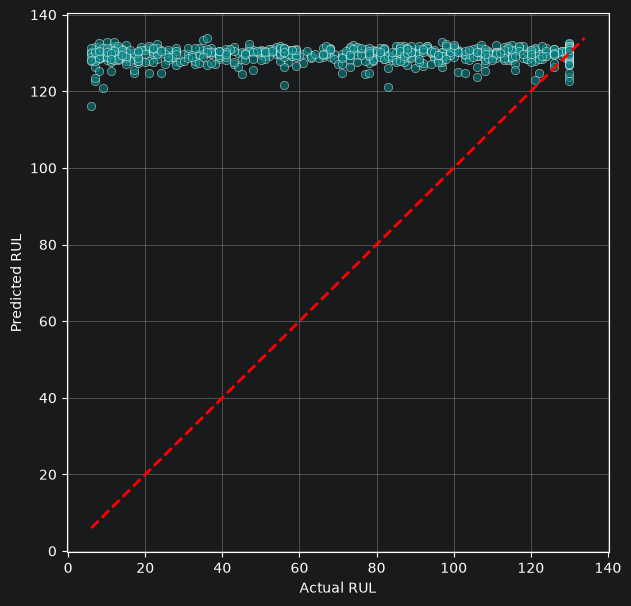

{'accuracy': 0.05091937765205092, 'rmse': np.float64(68.22530960789955)}


In [10]:
# Plot predictions vs actual
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.grid(True)
plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error

metrics = {
    'accuracy': accuracy_score(y_test, y_pred.astype(np.int32)),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred.astype(np.int32))),
}
print(metrics)

lastly hyperparametrizastion

In [ ]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
    }
    model = XGBRegressor(**params, early_stopping_rounds=20, eval_metric='rmse', random_state=42)
    model.fit(X_train_scaled, y_train_log, eval_set=[(X_val_scaled, y_val_log)], verbose=False)
    pred = model.predict(X_val_scaled)
    return np.sqrt(np.mean((np.expm1(pred) - np.expm1(y_val_log))**2))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_params = study.best_params

In [ ]:
import numpy as np
import polars as pl
import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns


def aggregate_epoch(epoch):
    """
    epoch: 2D array (window_length, num_features)
    Returns: 1D array of aggregated features per feature (mean, std, high_percentile, low_percentile, slope, delta)
    """
    mean = np.mean(epoch, axis=0)
    std = np.std(epoch, axis=0)
    high = np.percentile(epoch, 97, axis=0)
    low = np.percentile(epoch, 3, axis=0)

    W = epoch.shape[0]
    slope = np.polyfit(np.arange(W), epoch, 1)[0] if W > 1 else np.zeros(epoch.shape[1])
    delta = epoch[-1] - epoch[0] if W > 0 else np.zeros(epoch.shape[1])

    return np.concatenate([mean, std, high, low, slope, delta])


def build_training_data_with_ids_epoch(df, feature_cols, window=30):
    """
    Uses a sliding window of fixed length 'window' and returns engine IDs.
    window: number of cycles per sample (e.g., 30)
    """
    X_list, y_list, id_list = [], [], []

    for _, group in df.group_by(["file_path", "Unit"]):
        engine_id = group["Unit"][0]
        group = group.sort("Cycle")  # ascending order: earliest first
        data = group[feature_cols].to_numpy()
        labels = group["RUL"].to_numpy()
        L = data.shape[0]

        # We can create a sample for each possible window ending at i (i from window-1 to L-1)
        for i in range(window - 1, L):
            window_data = data[i - window + 1: i + 1]  # most recent 'window' cycles ending at i
            features = aggregate_epoch(window_data)
            X_list.append(features)
            y_list.append(labels[i])
            id_list.append(engine_id)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(id_list)


def build_test_data_with_ids_epoch(df, labels, feature_cols, window=30):
    """
    For each test engine, take the last 'window' cycles (pad at the beginning if needed)
    and aggregate features. Labels are provided separately.
    """
    X_list, y_list, id_list = [], [], []

    for idx, (_, group) in enumerate(df.group_by(["file_path", "Unit"])):
        engine_id = group["Unit"][0]
        group = group.sort("Cycle")  # ascending order
        data = group[feature_cols].to_numpy()
        L = data.shape[0]

        # Pad at the beginning with zeros if L < window
        if L < window:
            pad_len = window - L
            data = np.vstack([np.zeros((pad_len, data.shape[1])), data])
            L = data.shape[0]  # now L = window

        # Use the last 'window' cycles (the entire padded data)
        window_data = data[-window:]  # shape (window, F)
        features = aggregate_epoch(window_data)

        X_list.append(features)
        y_list.append(labels[idx])  # labels are provided per engine in order
        id_list.append(engine_id)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(id_list)


COLS = ["Unit", "Cycle", "Os1", "Os2", "Os3"] + [f"Sens_{i}" for i in range(21)]

lazy_df = pl.scan_csv(
    f"../CMAPSSData/train_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
)
processed_lazy_df = lazy_df.with_columns(
    (pl.col("Cycle").max().over(["file_path", "Unit"]) - pl.col("Cycle")).alias("RUL")
).drop(["column_27", "column_28"])

df = processed_lazy_df.collect()

WINDOW = 30
FEATURES = [
    'Cycle', 'Os1', 'Os2', 'Os3',
    "Sens_1", "Sens_2", "Sens_3", "Sens_5", "Sens_6", "Sens_7", "Sens_8", "Sens_9",
    'Sens_10', 'Sens_11', 'Sens_12', 'Sens_13', 'Sens_16', 'Sens_19', "Sens_20"
]

MAX_RUL = 130

X_train, y_train, engine_ids = build_training_data_with_ids_epoch(df, FEATURES, WINDOW)
y_train = np.clip(y_train, 0, MAX_RUL)

# Optional: log-transform target for better distribution (uncomment if desired)
# y_train = np.log1p(y_train)

# Split by engine: keep 20% of engines for validation
unique_engines = np.unique(engine_ids)
np.random.seed(42)
val_engines = np.random.choice(unique_engines, size=int(0.2 * len(unique_engines)), replace=False)
train_mask = np.isin(engine_ids, val_engines, invert=True)
val_mask = np.isin(engine_ids, val_engines)

X_train_split, y_train_split = X_train[train_mask], y_train[train_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    device='cuda'  # if GPU available
)

model.fit(
    X_train_scaled, y_train_split,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Load test data and labels
test_df = pl.scan_csv(
    f"../CMAPSSData/test_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
).drop(["column_27", "column_28"]).collect()

test_labels = pl.read_csv(
    f"../CMAPSSData/RUL_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
).select(pl.nth(0)).to_numpy().ravel()

# Clip test labels to same maximum
test_labels = np.clip(test_labels, 0, MAX_RUL)

# Optional: log-transform test labels if used for training
# test_labels = np.log1p(test_labels)

X_test, y_test, y_test_ids = build_test_data_with_ids_epoch(test_df, test_labels, FEATURES, WINDOW)
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Plot predictions vs actual
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.grid(True)
plt.show()

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")